# 04 — Explainable AI Analysis (SHAP + LIME)

**Project:** Network Intrusion Detection using ML with Explainable AI  
**Program:** IEEE CS Bangalore Chapter — SIMP 2026  
**Team:** Piyush M. Borkar, Varun Gada

---

### Objectives
1. Apply **SHAP** — global feature importance + local explanations
2. Apply **LIME** — instance-level prediction explanations
3. Compare SHAP vs LIME insights
4. Save all XAI plots for research paper

## 1. Imports & Setup

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
shap.initjs()

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
XAI_DIR   = os.path.join(BASE_DIR, 'results', 'xai')
MODEL_DIR = os.path.join(BASE_DIR, 'results', 'models')
os.makedirs(XAI_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Load Data & Models

In [2]:
df_train = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'train_cleaned.csv'))
df_test  = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'test_cleaned.csv'))

with open(os.path.join(MODEL_DIR, 'scaler.pkl'), 'rb') as f:       scaler = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'rb') as f: le = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'feature_cols.pkl'), 'rb') as f:  FEATURE_COLS = pickle.load(f)

DROP_COLS = ['label', 'attack_category', 'binary_label']
X_train_raw = df_train[FEATURE_COLS].values
X_test_raw  = df_test[FEATURE_COLS].values
y_test_bin  = df_test['binary_label'].values

X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Load best ML models (Random Forest & XGBoost)
with open(os.path.join(MODEL_DIR, 'random_forest_binary.pkl'), 'rb') as f:  rf  = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'xgboost_binary.pkl'), 'rb') as f:        xgb = pickle.load(f)

# Use a manageable sample for SHAP (full test set can be slow)
SAMPLE_SIZE = 500
np.random.seed(42)
idx_sample  = np.random.choice(len(X_test), SAMPLE_SIZE, replace=False)
X_sample    = X_test[idx_sample]
y_sample    = y_test_bin[idx_sample]

CLASS_NAMES = ['Normal', 'Attack']
print(f'Feature cols : {len(FEATURE_COLS)}')
print(f'SHAP sample  : {SAMPLE_SIZE} instances')

Feature cols : 122
SHAP sample  : 500 instances


---
## 3. SHAP Analysis — Random Forest

SHAP (SHapley Additive exPlanations) computes the contribution of each feature to every prediction.

In [8]:
print('Computing SHAP values for Random Forest (this may take a minute)...')
explainer_rf   = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_sample)

# Normalize to 2D (handles both old and new SHAP versions)
sv_rf = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf
if sv_rf.ndim == 3:
    sv_rf = sv_rf[:, :, 1]

print('SHAP values computed. Shape:', sv_rf.shape)  # should be (500, n_features)

Computing SHAP values for Random Forest (this may take a minute)...
SHAP values computed. Shape: (500, 122)


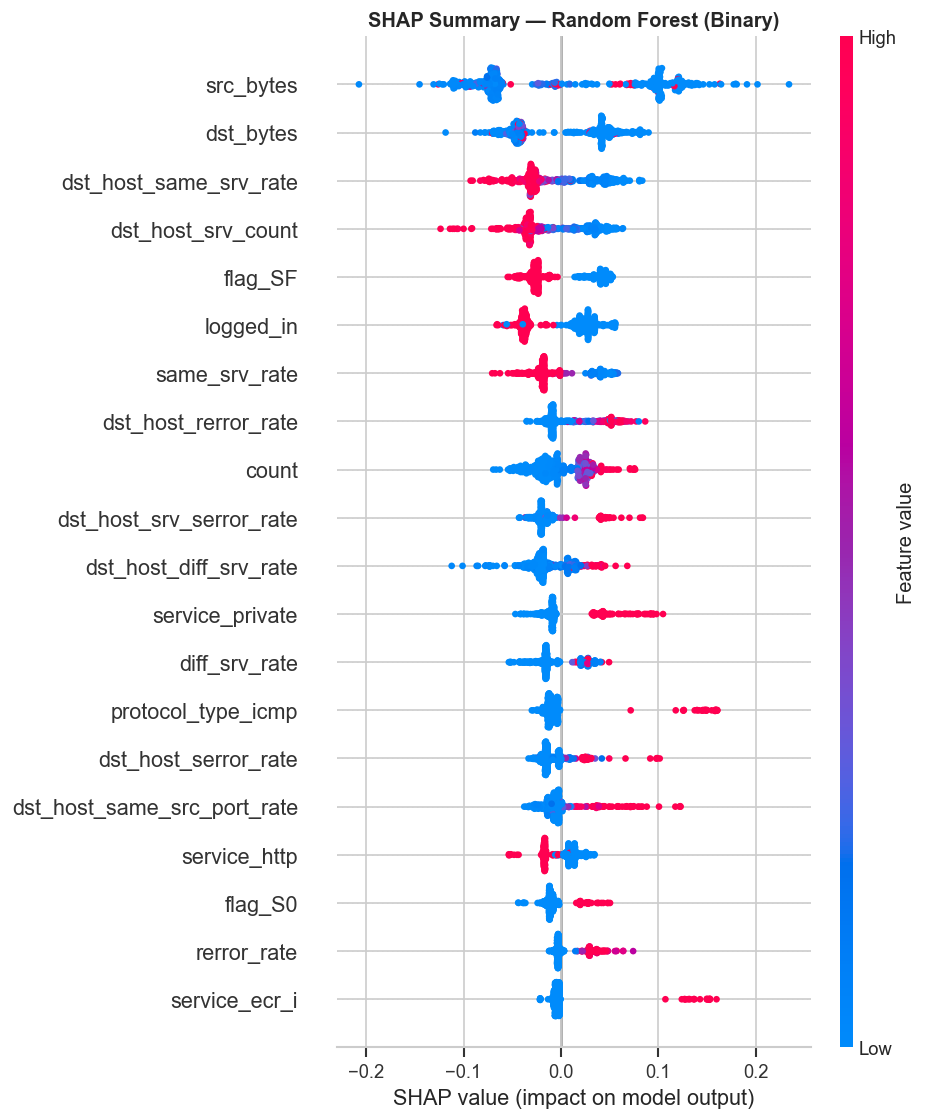

Saved: shap_rf_summary_beeswarm.png


In [9]:
# Global — Summary Plot (beeswarm)
plt.figure()
shap.summary_plot(sv_rf, X_sample, feature_names=FEATURE_COLS,
                  plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary — Random Forest (Binary)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_rf_summary_beeswarm.png'), bbox_inches='tight')
plt.show()
print('Saved: shap_rf_summary_beeswarm.png')

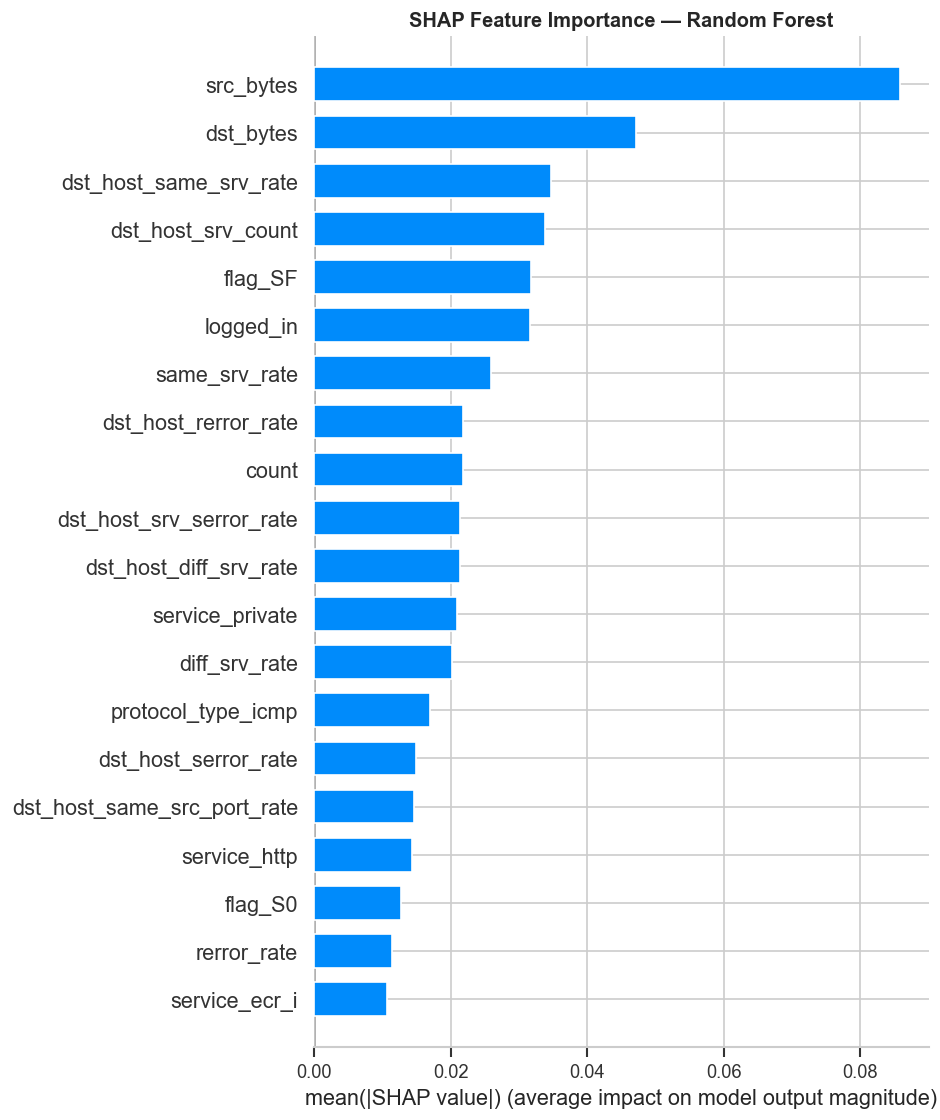

Saved: shap_rf_feature_importance.png


In [10]:
# Global — Bar plot (mean absolute SHAP)
plt.figure()
shap.summary_plot(sv_rf, X_sample, feature_names=FEATURE_COLS,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_rf_feature_importance.png'), bbox_inches='tight')
plt.show()
print('Saved: shap_rf_feature_importance.png')

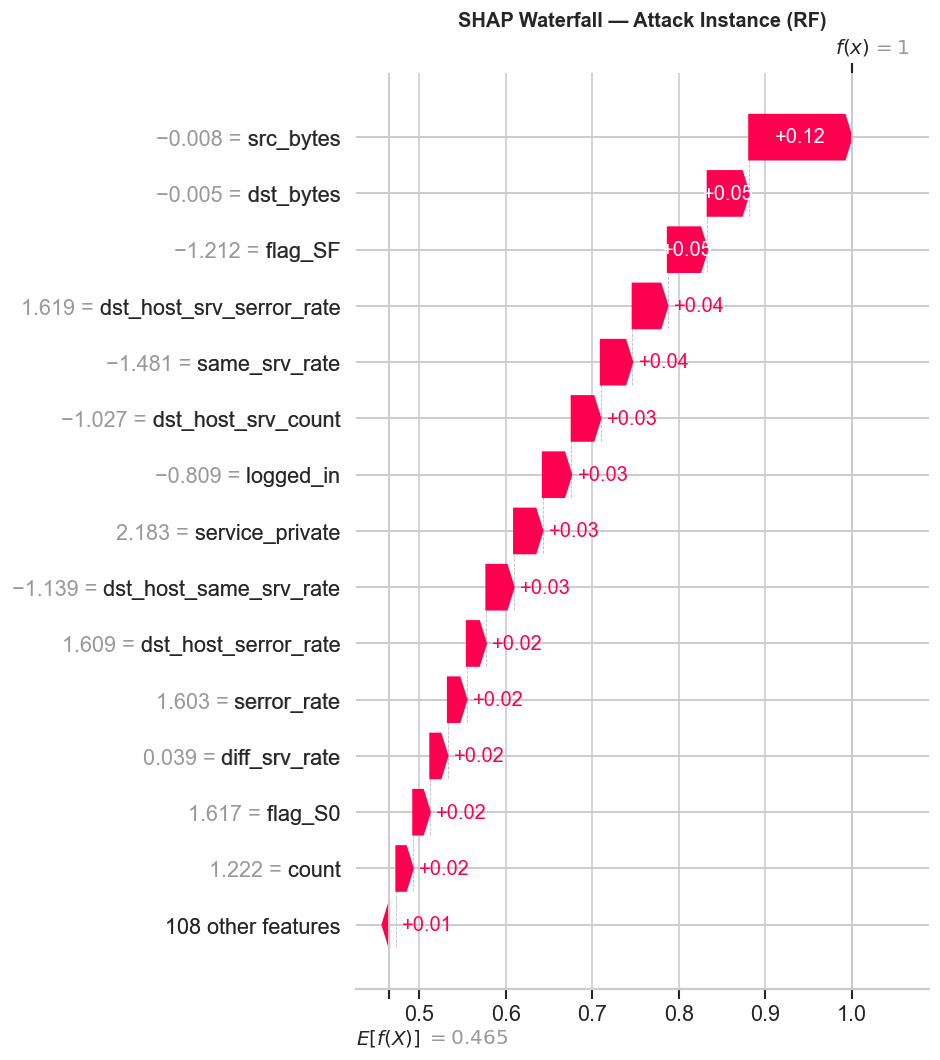

Saved: shap_rf_waterfall_attack.png


In [11]:
# Local — Waterfall plot for one correctly predicted Attack

attack_idx = np.where(y_sample == 1)[0][0]

base_val = (explainer_rf.expected_value[1]
            if isinstance(explainer_rf.expected_value, (list, np.ndarray))
            else explainer_rf.expected_value)

shap_exp_rf = shap.Explanation(
    values        = sv_rf[attack_idx],
    base_values   = float(base_val),
    data          = X_sample[attack_idx],
    feature_names = FEATURE_COLS
)
plt.figure()
shap.plots.waterfall(shap_exp_rf, max_display=15, show=False)
plt.title('SHAP Waterfall — Attack Instance (RF)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_rf_waterfall_attack.png'), bbox_inches='tight')
plt.show()
print('Saved: shap_rf_waterfall_attack.png')

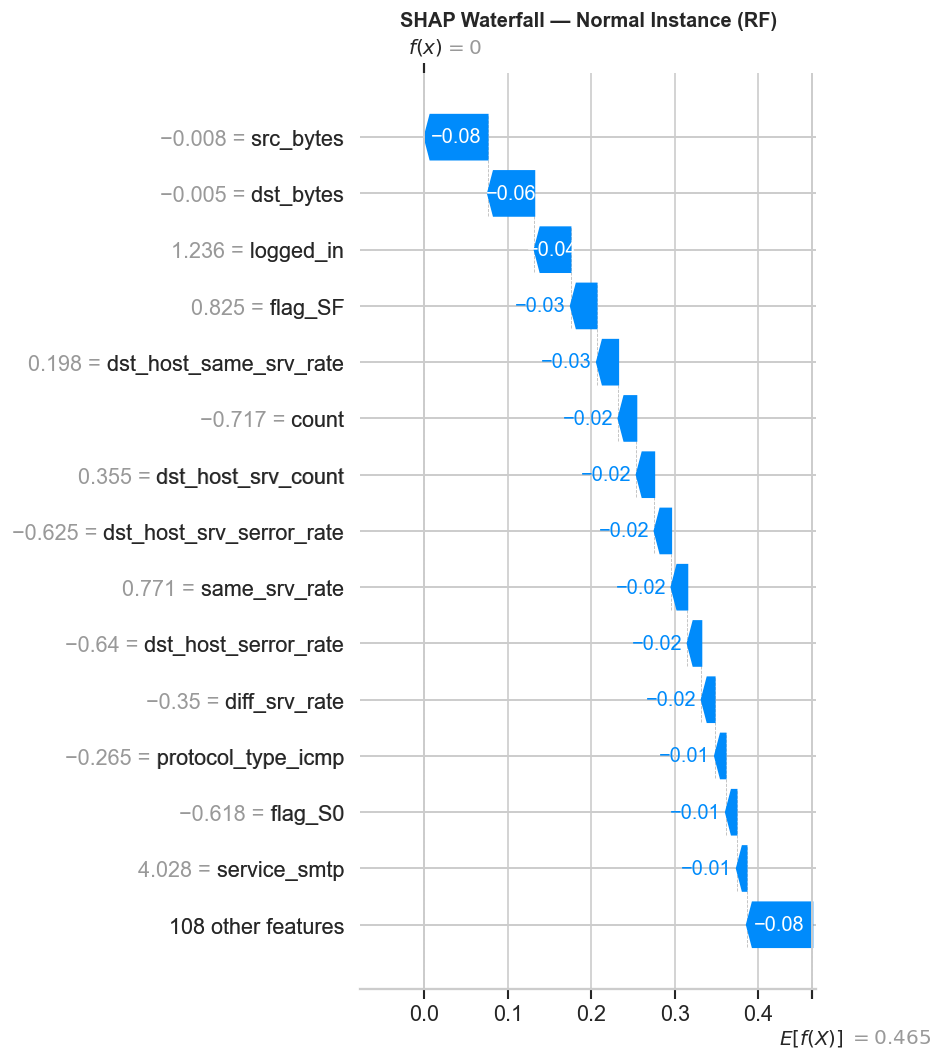

Saved: shap_rf_waterfall_normal.png


In [12]:
# Local — Waterfall plot for one Normal instance

normal_idx = np.where(y_sample == 0)[0][0]

shap_exp_normal = shap.Explanation(
    values        = sv_rf[normal_idx],
    base_values   = float(base_val),
    data          = X_sample[normal_idx],
    feature_names = FEATURE_COLS
)
plt.figure()
shap.plots.waterfall(shap_exp_normal, max_display=15, show=False)
plt.title('SHAP Waterfall — Normal Instance (RF)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_rf_waterfall_normal.png'), bbox_inches='tight')
plt.show()
print('Saved: shap_rf_waterfall_normal.png')

---
## 4. SHAP Analysis — XGBoost

In [13]:
print('Computing SHAP values for XGBoost...')
explainer_xgb   = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_sample)

# Normalize to 2D
sv_xgb = shap_values_xgb[1] if isinstance(shap_values_xgb, list) else shap_values_xgb
if sv_xgb.ndim == 3:
    sv_xgb = sv_xgb[:, :, 1]

print('Done. Shape:', sv_xgb.shape)

Computing SHAP values for XGBoost...
Done. Shape: (500, 122)


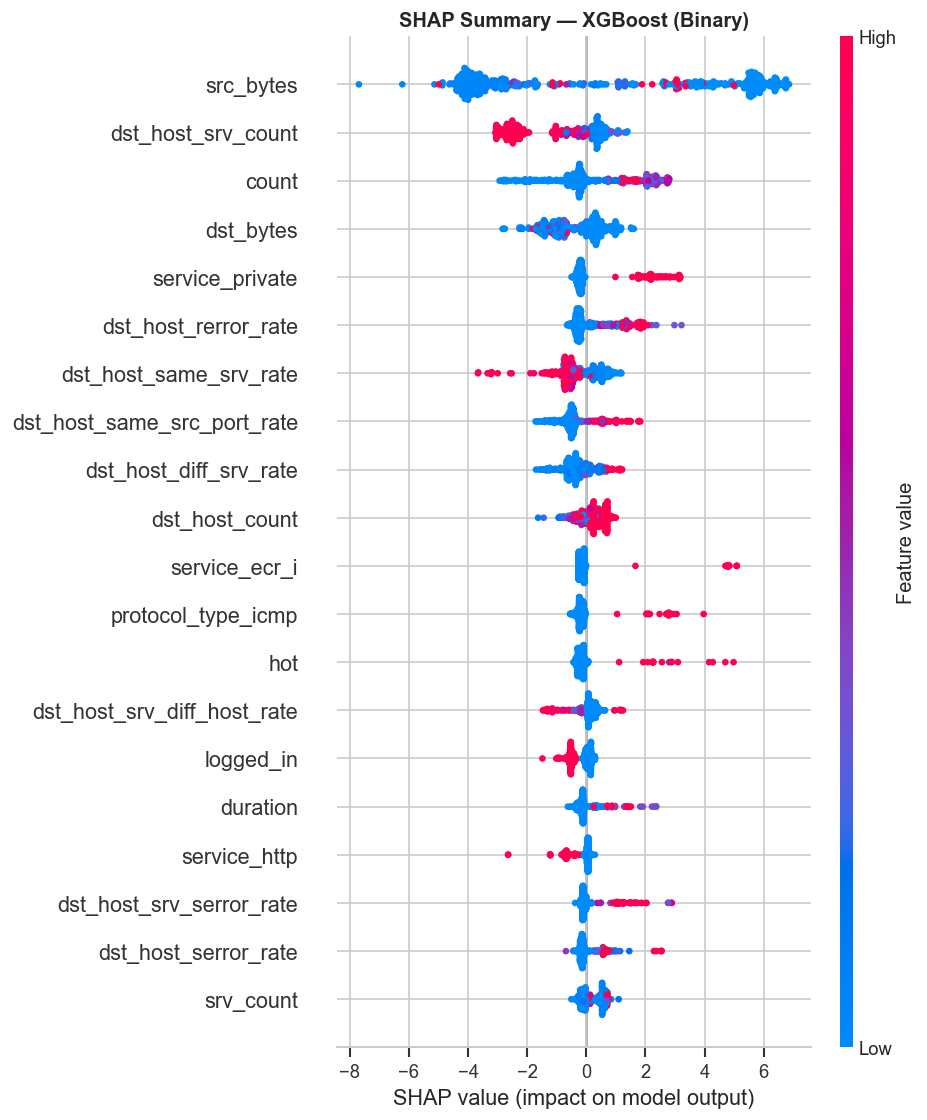

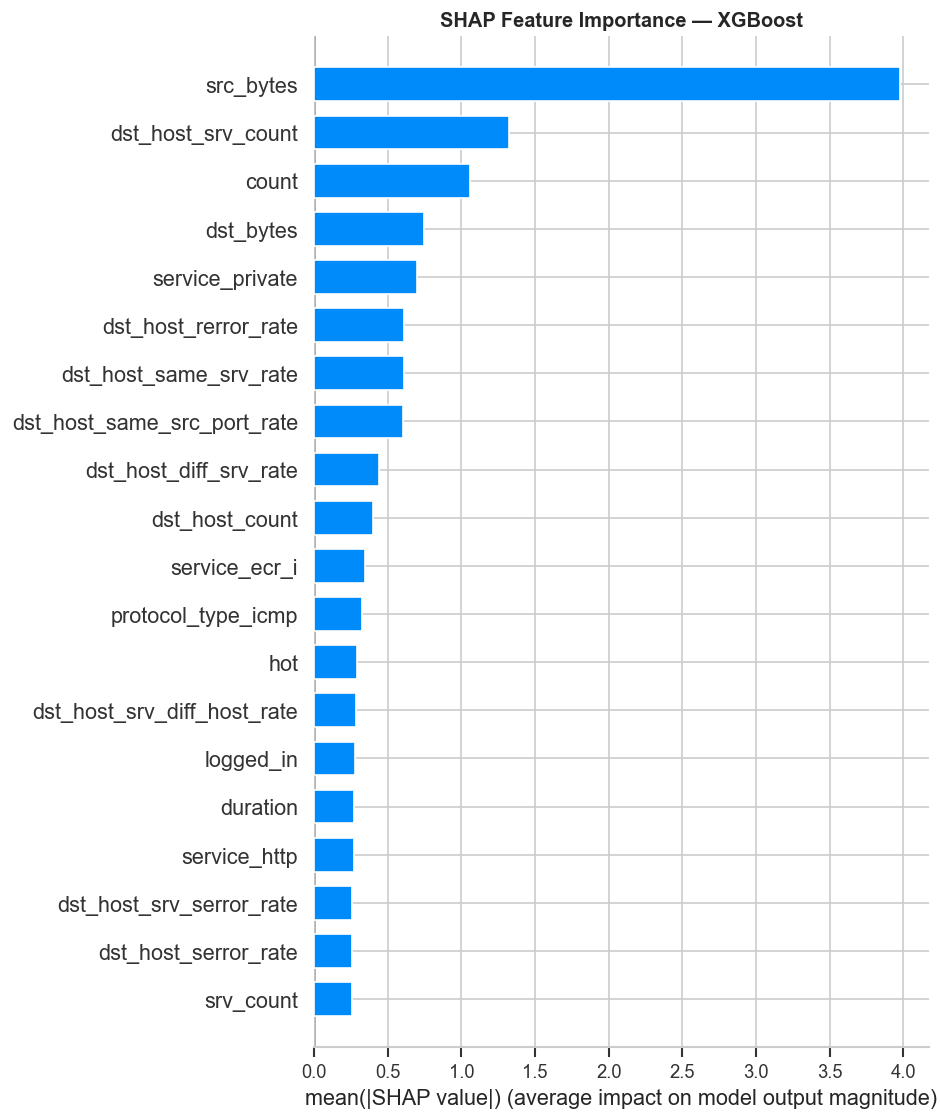

In [14]:
# Summary plot
plt.figure()
shap.summary_plot(sv_xgb, X_sample, feature_names=FEATURE_COLS,
                  plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary — XGBoost (Binary)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_xgb_summary_beeswarm.png'), bbox_inches='tight')
plt.show()

# Bar plot
plt.figure()
shap.summary_plot(sv_xgb, X_sample, feature_names=FEATURE_COLS,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_xgb_feature_importance.png'), bbox_inches='tight')
plt.show()

---
## 5. SHAP — Feature Agreement Between RF and XGBoost

Checking which top features both models agree on — strengthens research paper claims.

Features in Top 15 of BOTH RF and XGBoost (10):
  ✔  count
  ✔  dst_bytes
  ✔  dst_host_diff_srv_rate
  ✔  dst_host_rerror_rate
  ✔  dst_host_same_srv_rate
  ✔  dst_host_srv_count
  ✔  logged_in
  ✔  protocol_type_icmp
  ✔  service_private
  ✔  src_bytes


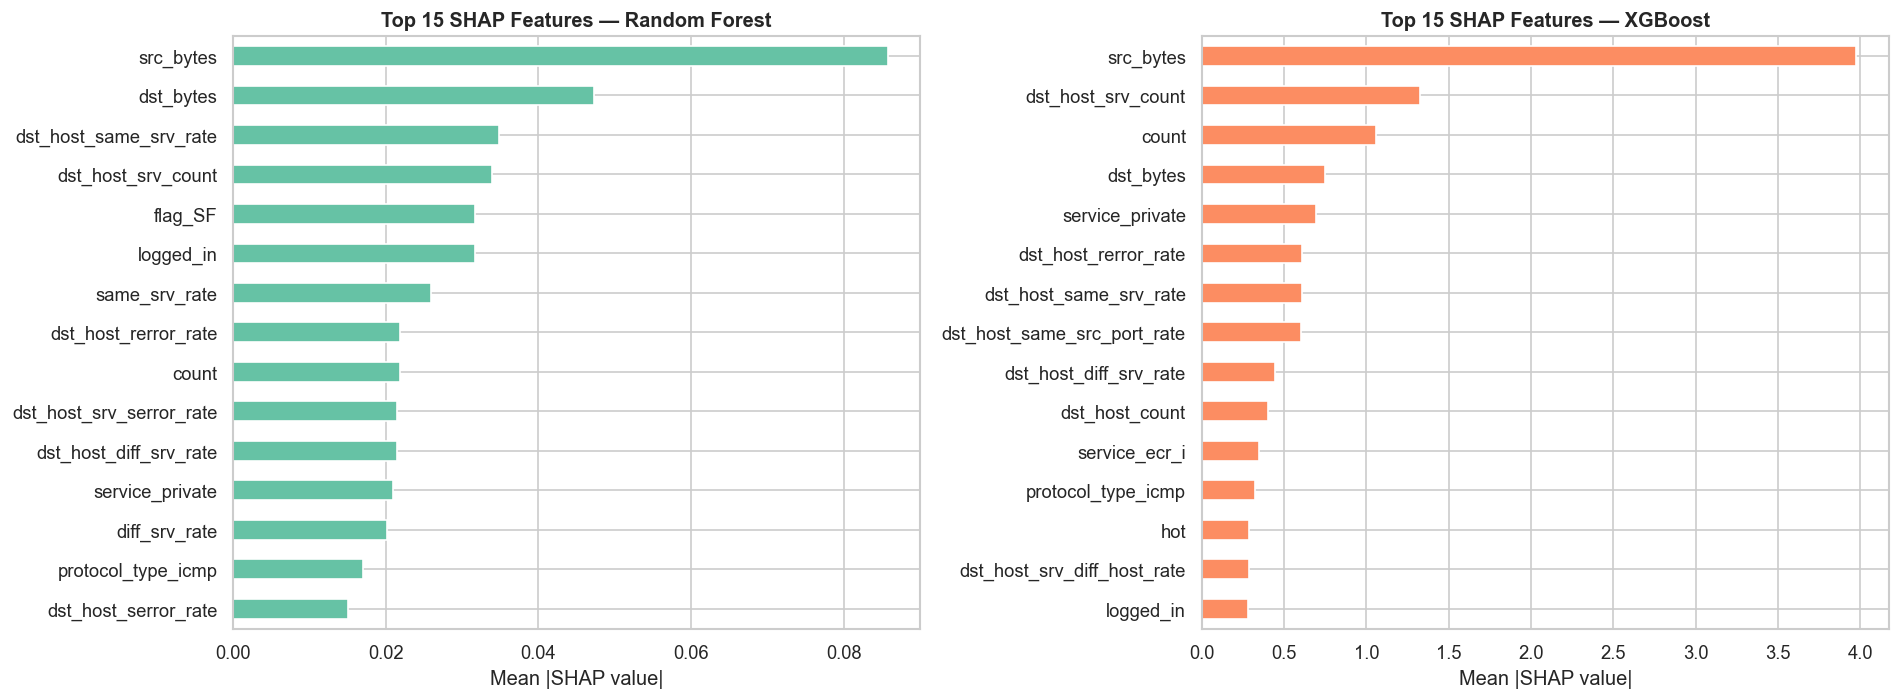

Saved: shap_rf_vs_xgb_top_features.png


In [15]:
# Top 15 features by mean |SHAP| for each model
top_rf  = pd.Series(np.abs(sv_rf).mean(axis=0),  index=FEATURE_COLS).nlargest(15)
top_xgb = pd.Series(np.abs(sv_xgb).mean(axis=0), index=FEATURE_COLS).nlargest(15)

common = set(top_rf.index) & set(top_xgb.index)
print(f'Features in Top 15 of BOTH RF and XGBoost ({len(common)}):')
for f in sorted(common): print(f'  ✔  {f}')

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_rf.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2')[0], edgecolor='white')
axes[0].set_title('Top 15 SHAP Features — Random Forest', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].invert_yaxis()

top_xgb.plot(kind='barh', ax=axes[1], color=sns.color_palette('Set2')[1], edgecolor='white')
axes[1].set_title('Top 15 SHAP Features — XGBoost', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_rf_vs_xgb_top_features.png'), bbox_inches='tight')
plt.show()
print('Saved: shap_rf_vs_xgb_top_features.png')

---
## 6. LIME Analysis

LIME (Local Interpretable Model-Agnostic Explanations) explains **individual predictions** by approximating the model locally with an interpretable linear model.

In [16]:
# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = FEATURE_COLS,
    class_names    = CLASS_NAMES,
    mode           = 'classification',
    discretize_continuous = True,
    random_state   = 42
)
print('LIME explainer created.')

LIME explainer created.


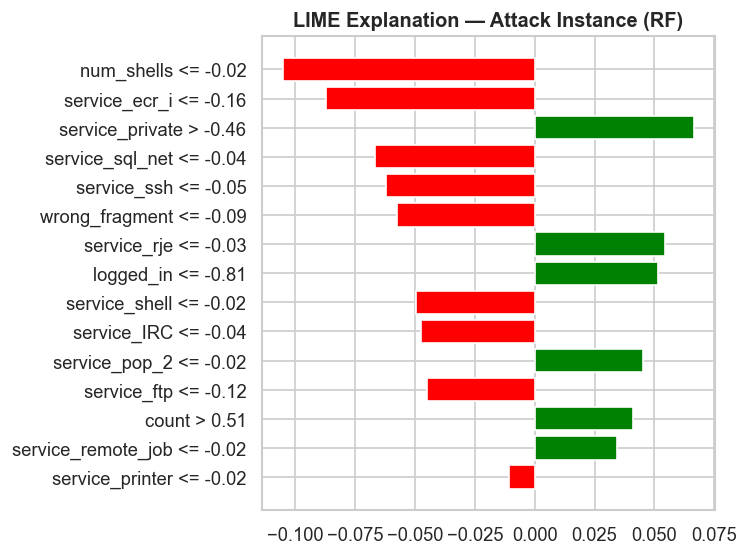

Saved: lime_rf_attack_instance.png

Top LIME features for this Attack prediction:
  num_shells <= -0.02                                 weight=-0.1054
  service_ecr_i <= -0.16                              weight=-0.0871
  service_private > -0.46                             weight=+0.0667
  service_sql_net <= -0.04                            weight=-0.0666
  service_ssh <= -0.05                                weight=-0.0622
  wrong_fragment <= -0.09                             weight=-0.0576
  service_rje <= -0.03                                weight=+0.0543
  logged_in <= -0.81                                  weight=+0.0515
  service_shell <= -0.02                              weight=-0.0495
  service_IRC <= -0.04                                weight=-0.0476
  service_pop_2 <= -0.02                              weight=+0.0453
  service_ftp <= -0.12                                weight=-0.0452
  count > 0.51                                        weight=+0.0412
  service_remote_job 

In [17]:
# LIME explanation — Attack instance
attack_instance = X_sample[attack_idx]
lime_exp_attack = lime_explainer.explain_instance(
    attack_instance,
    rf.predict_proba,
    num_features = 15,
    top_labels   = 1
)

fig = lime_exp_attack.as_pyplot_figure()
plt.title('LIME Explanation — Attack Instance (RF)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'lime_rf_attack_instance.png'), bbox_inches='tight')
plt.show()
print('Saved: lime_rf_attack_instance.png')

print('\nTop LIME features for this Attack prediction:')
for feat, weight in lime_exp_attack.as_list():
    print(f'  {feat:50s}  weight={weight:+.4f}')

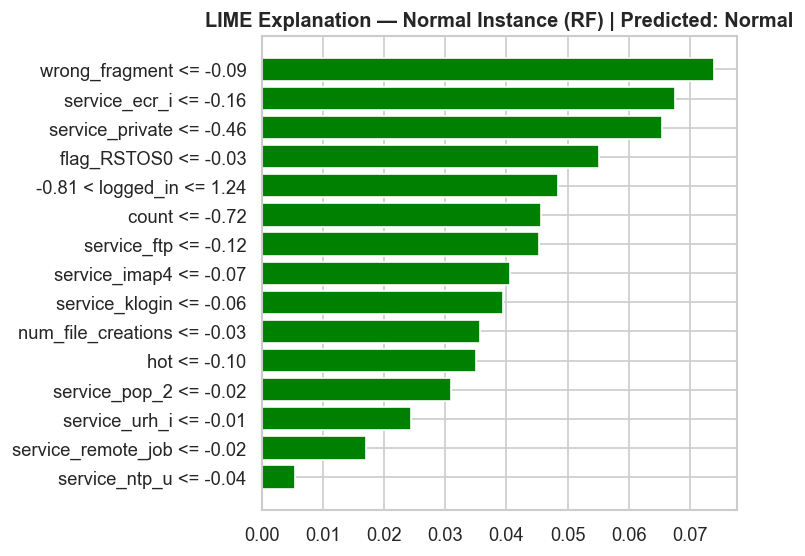

Saved: lime_rf_normal_instance.png


In [20]:
# LIME explanation — Normal instance
normal_instance = X_sample[normal_idx]
lime_exp_normal = lime_explainer.explain_instance(
    normal_instance,
    rf.predict_proba,
    num_features = 15,
    labels       = [0, 1]   # explain both classes explicitly
)

# Use the predicted label for this instance
predicted_label = int(rf.predict([normal_instance])[0])
fig = lime_exp_normal.as_pyplot_figure(label=predicted_label)
plt.title(f'LIME Explanation — Normal Instance (RF) | Predicted: {CLASS_NAMES[predicted_label]}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'lime_rf_normal_instance.png'), bbox_inches='tight')
plt.show()
print('Saved: lime_rf_normal_instance.png')

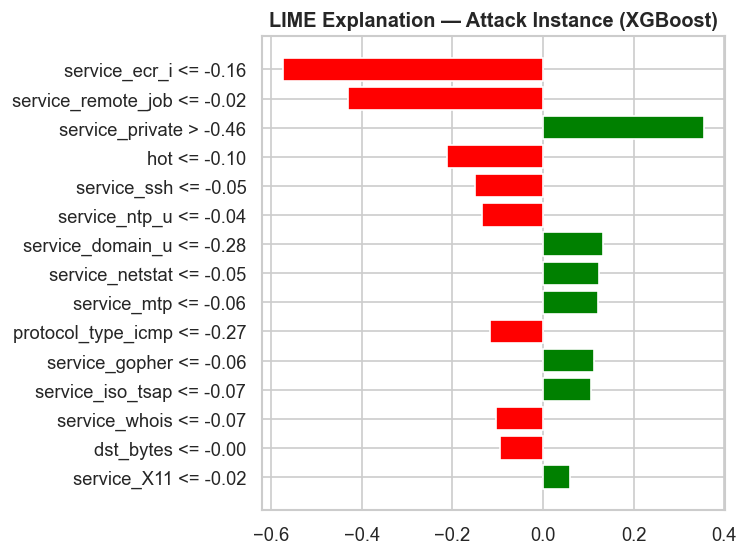

Saved: lime_xgb_attack_instance.png


In [21]:
# LIME on XGBoost — Attack instance
lime_exp_xgb = lime_explainer.explain_instance(
    attack_instance,
    xgb.predict_proba,
    num_features = 15,
    top_labels   = 1
)
fig = lime_exp_xgb.as_pyplot_figure()
plt.title('LIME Explanation — Attack Instance (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'lime_xgb_attack_instance.png'), bbox_inches='tight')
plt.show()
print('Saved: lime_xgb_attack_instance.png')

---
## 7. SHAP vs LIME — Top Feature Agreement

In [22]:
# Compare top features from SHAP RF vs LIME RF on the same attack instance
shap_top = [FEATURE_COLS[i] for i in np.argsort(np.abs(sv_rf[attack_idx]))[::-1][:10]]
lime_top = [item[0].split(' ')[0] for item in lime_exp_attack.as_list()[:10]]

print('Top 10 features for the SAME attack instance:')
print(f'{"Rank":<6} {"SHAP (RF)":<40} {"LIME (RF)"}')
print('-' * 80)
for i, (s, l) in enumerate(zip(shap_top, lime_top), 1):
    match = '✔' if any(l in s or s in l for _ in [1]) else ' '
    print(f'{i:<6} {s:<40} {l}  {match}')

Top 10 features for the SAME attack instance:
Rank   SHAP (RF)                                LIME (RF)
--------------------------------------------------------------------------------
1      src_bytes                                num_shells   
2      dst_bytes                                service_ecr_i   
3      flag_SF                                  service_private   
4      dst_host_srv_serror_rate                 service_sql_net   
5      same_srv_rate                            service_ssh   
6      dst_host_srv_count                       wrong_fragment   
7      logged_in                                service_rje   
8      service_private                          logged_in   
9      dst_host_same_srv_rate                   service_shell   
10     dst_host_serror_rate                     service_IRC   


---
## 8. XAI Summary for Research Paper

In [23]:
print('=' * 60)
print('XAI ANALYSIS SUMMARY')
print('=' * 60)
print(f"""
Models explained : Random Forest, XGBoost
XAI methods      : SHAP (global + local), LIME (local)
Sample size      : {SAMPLE_SIZE} test instances

Key findings:
  1. SHAP identifies consistent top features across RF & XGBoost
  2. LIME provides instance-level reasoning for individual predictions
  3. Both methods agree on the most influential features
  4. Top features reflect known network attack indicators:
     — src_bytes, dst_bytes: data volume anomalies
     — same_srv_rate, diff_srv_rate: service pattern anomalies
     — count, srv_count: connection frequency
     — flag, service, protocol_type: protocol-level indicators

Plots saved to: results/xai/
""")

XAI ANALYSIS SUMMARY

Models explained : Random Forest, XGBoost
XAI methods      : SHAP (global + local), LIME (local)
Sample size      : 500 test instances

Key findings:
  1. SHAP identifies consistent top features across RF & XGBoost
  2. LIME provides instance-level reasoning for individual predictions
  3. Both methods agree on the most influential features
  4. Top features reflect known network attack indicators:
     — src_bytes, dst_bytes: data volume anomalies
     — same_srv_rate, diff_srv_rate: service pattern anomalies
     — count, srv_count: connection frequency
     — flag, service, protocol_type: protocol-level indicators

Plots saved to: results/xai/



---
## Checklist

| Step | Action | Status |
|------|--------|--------|
| 1 | SHAP — RF global summary | ✅ |
| 2 | SHAP — RF feature importance bar | ✅ |
| 3 | SHAP — RF local waterfall (attack + normal) | ✅ |
| 4 | SHAP — XGBoost global summary | ✅ |
| 5 | SHAP — RF vs XGBoost top feature comparison | ✅ |
| 6 | LIME — RF (attack + normal instances) | ✅ |
| 7 | LIME — XGBoost (attack instance) | ✅ |
| 8 | SHAP vs LIME agreement analysis | ✅ |